# CNC Predictive Maintenance


## Import Dataset


Load required libraries and data loader utils to extract the CNC dataset from the local .h5 files. This dataset contains vibration sensor data from CNC machines, which will be used for predicitve maintenance analysis.


In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from utils import data_loader_utils
import itertools

The dataset is organized hierachically, with each machine having its own folder. Each machine folder contains operation folders (e.g. `op1`, `op2`, etc.). Within each operation folder, there are `good` and `bad` folders. The `good` folders contain .h5 files with vibration data from normal machine operations, while the `bad` folders contain .h5 files with vibration data from machines that are experiencing faults or failures.


In [2]:
machines = ["M01", "M02", "M03"]
process_names = [
    "OP00",
    "OP01",
    "OP02",
    "OP03",
    "OP04",
    "OP05",
    "OP06",
    "OP07",
    "OP08",
    "OP09",
    "OP10",
    "OP11",
    "OP12",
    "OP13",
    "OP14",
]
labels = ["good", "bad"]
path_to_dataset = Path("../data/").absolute()

The data_generator function can efficiently load the .h5 data for analysis. It reads each .h5 file and extracts the data to an efficient dataframe for further analysis.


In [3]:
def data_generator():
    for process_name, machine, label in itertools.product(
        process_names, machines, labels
    ):
        data_path = os.path.join(path_to_dataset, machine, process_name, label)
        data_list, data_label = data_loader_utils.load_tool_research_data(
            data_path, label=label, verbose=False
        )

        for data_array, label_ in zip(data_list, data_label):
            # Break apart the label_
            # Example label_: M01_Aug_2019_OP00_000_good
            # Get M01, *, OP00, 000, good
            label_parts = label_.split("_")
            machine_id = label_parts[0]
            tool_operation_date = label_parts[1] + "_" + label_parts[2]
            tool_operation_id = label_parts[3]
            tool_operation_instance = int(label_parts[4])
            tool_operation_status = label_parts[5]

            yield [
                machine_id,
                tool_operation_id,
                tool_operation_instance,
                tool_operation_date,
                tool_operation_status,
                label_,
                data_array.astype(np.int16),
            ]


df = pd.DataFrame(
    data_generator(),
    columns=[
        "machine_id",
        "tool_operation_id",
        "tool_operation_instance",
        "tool_operation_date",
        "tool_operation_status",
        "label",
        "vibration_data",
    ],
)

display(df.head())
print(f"There are {len(df)} labeled samples of vibration data in the dataset.")

,machine_id,tool_operation_id,tool_operation_instance,tool_operation_date,tool_operation_status,label,vibration_data
0,M01,OP00,0,Aug_2019,good,M01_Aug_2019_OP00_000_good,"[[-9, 9, -1011], [-21, 19, -1011], [-15, 23, -..."
1,M01,OP00,1,Aug_2019,good,M01_Aug_2019_OP00_001_good,"[[-15, 21, -1009], [-13, 23, -1013], [-13, 19,..."
2,M01,OP00,3,Aug_2019,good,M01_Aug_2019_OP00_003_good,"[[-9, 15, -1018], [-27, 15, -1005], [-13, 21, ..."
3,M01,OP00,4,Aug_2019,good,M01_Aug_2019_OP00_004_good,"[[-33, 15, -1005], [-37, 7, -1011], [-35, 21, ..."
4,M01,OP00,5,Aug_2019,good,M01_Aug_2019_OP00_005_good,"[[-5, 17, -1016], [-17, 23, -1018], [-7, 42, -..."


There are 1702 labeled samples of vibration data in the dataset.


Each sample contains the following data:

- `machine_id`: Identifier for the CNC machine (M01, M02, or M03)
- `tool_operation_id`: Identifier for the tool operation (OP00 through OP14)
- `tool_operation_instance`: Instance number of the tool operation for the given machine and date
- `tool_operation_date`: Date the tool operation was performed (e.g., Aug_2019)
- `tool_operation_status`: Status of the tool operation (good or bad)
- `label`: Combined label of the above fields for easy identification
- `vibration_data`: Numpy array of vibration data collected during the tool operation
  - These are x,y,z axis vibration data sampled at 2 kHz from a tri-axial CISS sensor


## Example Data Samples


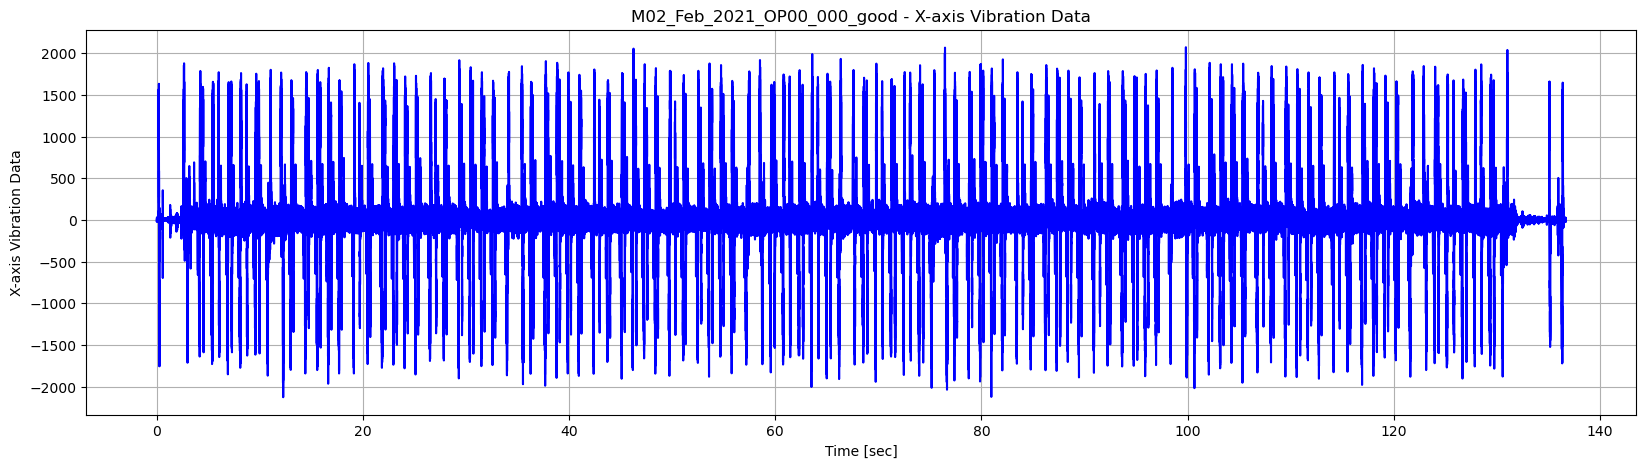

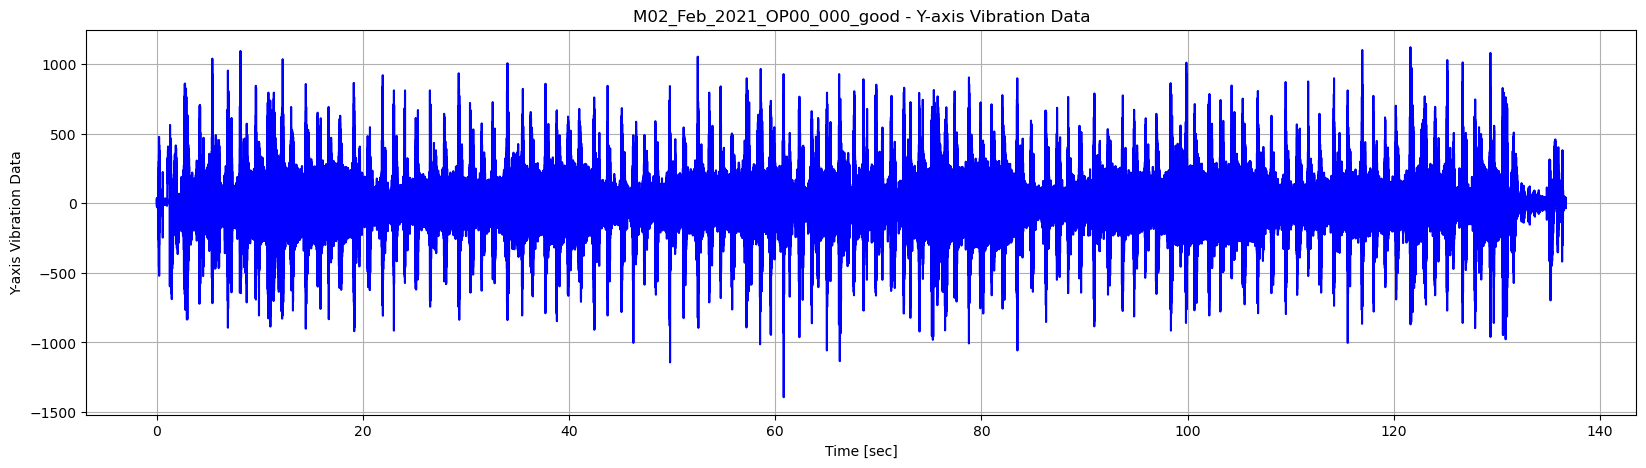

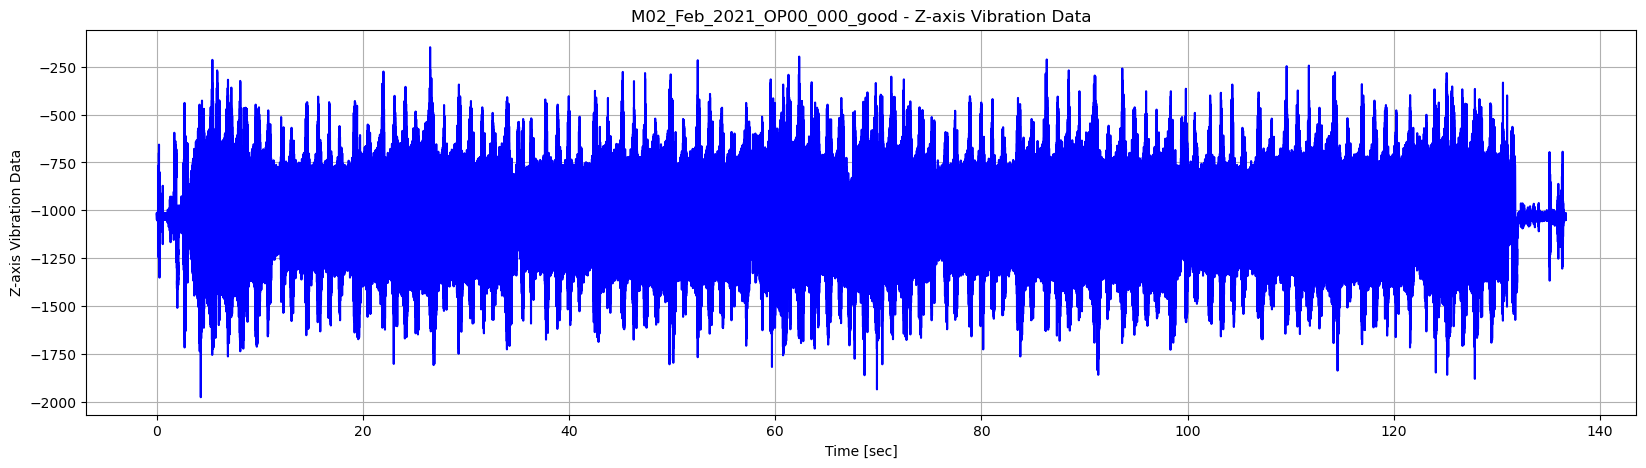

In [4]:
# plot good sample for reference
good_row = df[
    (df["machine_id"] == "M02")
    & (df["tool_operation_status"] == "good")
    & (df["tool_operation_id"] == "OP00")
    & (df["tool_operation_instance"] == 0)
    & (df["tool_operation_date"] == "Feb_2021")
].iloc[0]

data_loader_utils.plot_vibration_data(
    good_row["vibration_data"], label=good_row["label"]
)

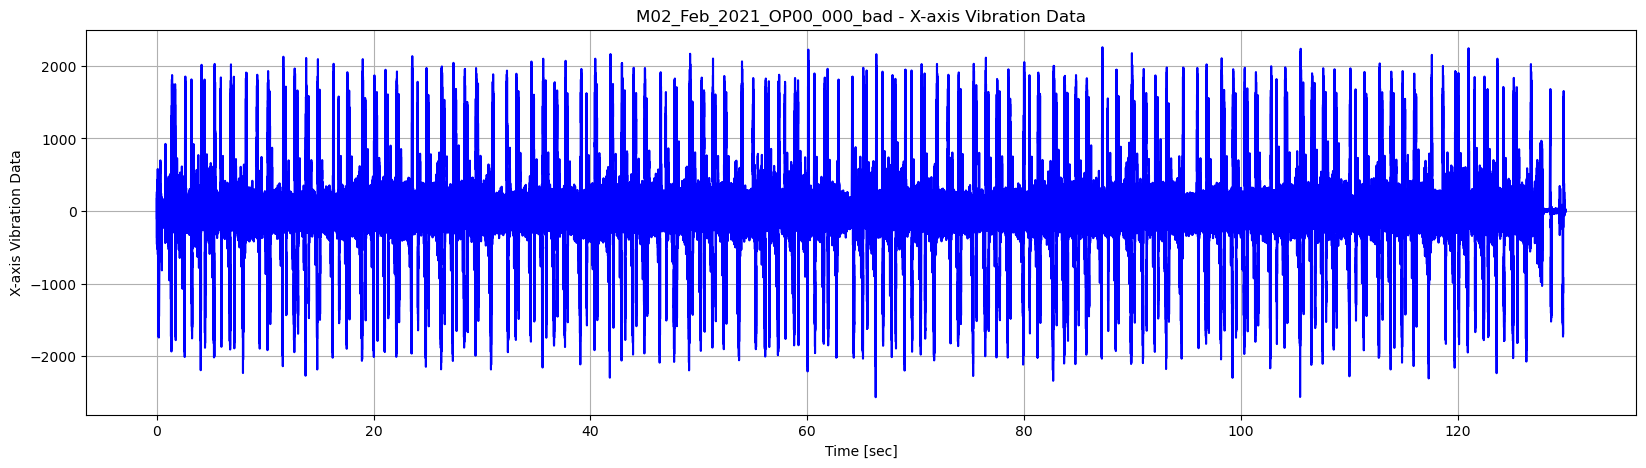

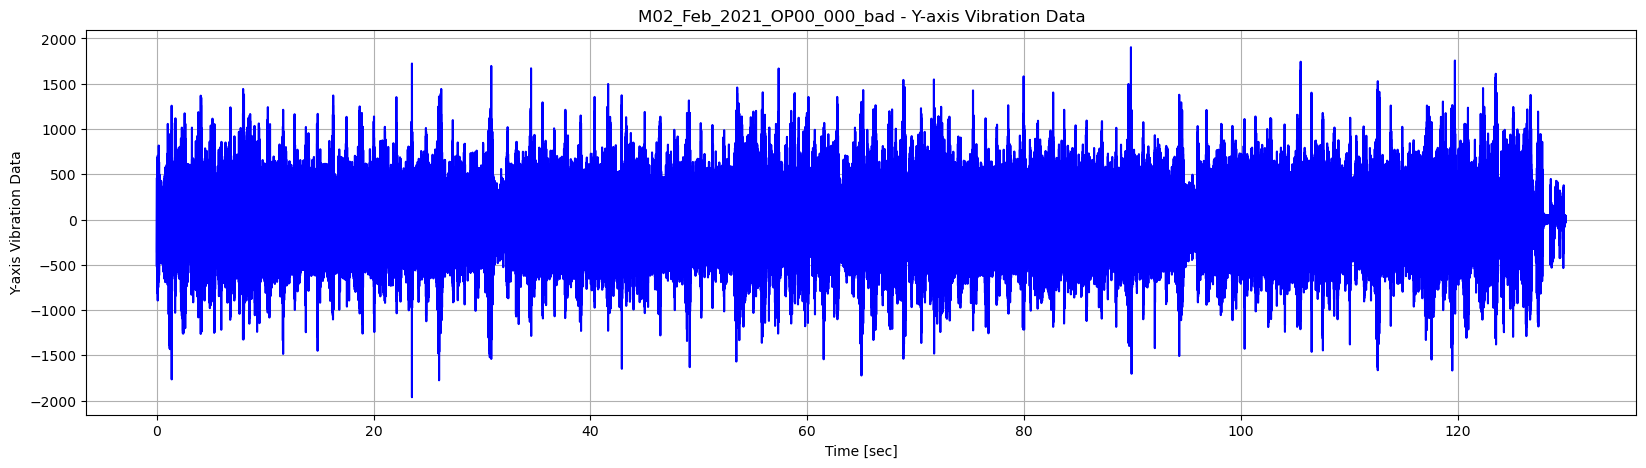

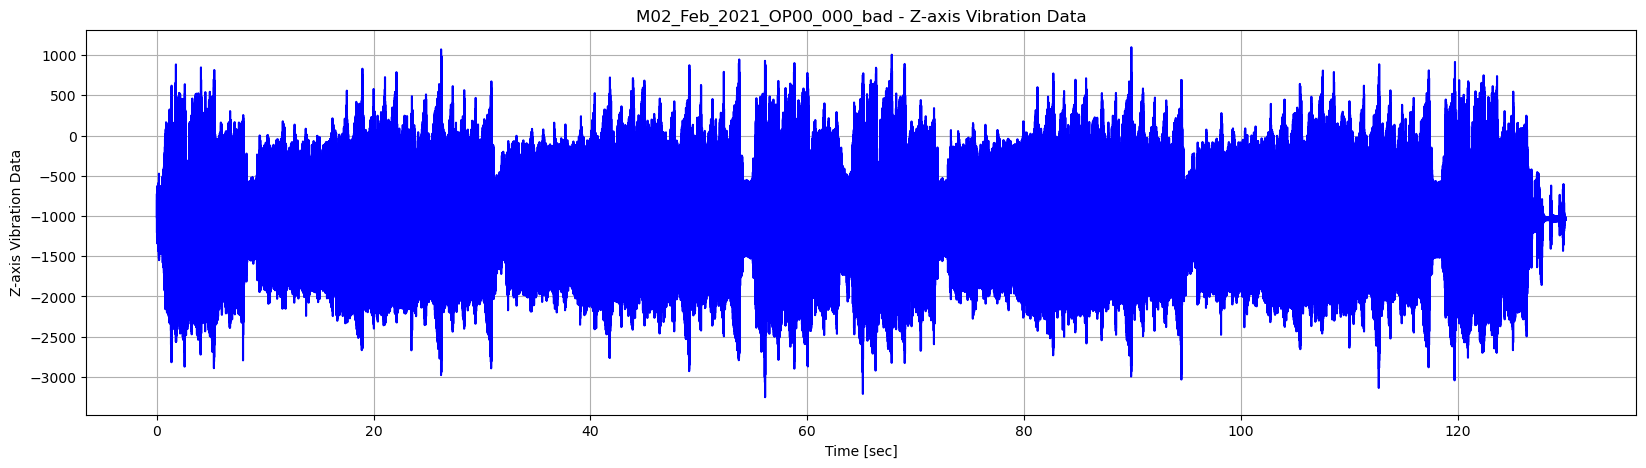

In [5]:
# plot bad sample for reference
bad_row = df[
    (df["machine_id"] == "M02")
    & (df["tool_operation_status"] == "bad")
    & (df["tool_operation_id"] == "OP00")
    & (df["tool_operation_instance"] == 0)
    & (df["tool_operation_date"] == "Feb_2021")
].iloc[0]

data_loader_utils.plot_vibration_data(bad_row["vibration_data"], label=bad_row["label"])

## Investigating temporal patterns and data quality

This section inspects temporal distribution of samples (by `tool_operation_date` and status) and checks data quality: missing values, inconsistent lengths, basic summary statistics, and outlier/anomaly detection using RMS + z-score (threshold = 3).


In [6]:
# Imports for analysis and plotting
import matplotlib.pyplot as plt
import seaborn as sns


# Compute basic per-sample statistics from the vibration arrays
def _extract_stats(arr):
    a = np.asarray(arr)
    # handle common tri-axial shape (N,3) or flat arrays
    if a.ndim == 2 and a.shape[1] == 3:
        length = a.shape[0]
        nan_count = int(np.isnan(a).sum())
        rms = float(np.sqrt(np.mean(a.astype(np.float64) ** 2)))
        max_abs = float(np.max(np.abs(a)))
        mean_x, mean_y, mean_z = [float(x) for x in a.mean(axis=0)]
    else:
        flat = a.ravel()
        length = flat.size
        nan_count = int(np.isnan(flat).sum())
        rms = float(np.sqrt(np.mean(flat.astype(np.float64) ** 2)))
        max_abs = float(np.max(np.abs(flat)))
        mean_x = mean_y = mean_z = np.nan
    return {
        "length": int(length),
        "nan_count": int(nan_count),
        "rms": rms,
        "max_abs": max_abs,
        "mean_x": mean_x,
        "mean_y": mean_y,
        "mean_z": mean_z,
    }


# apply and expand into dataframe columns
stats_df = df["vibration_data"].apply(lambda x: pd.Series(_extract_stats(x)))
df = pd.concat([df, stats_df], axis=1)

# Quick summary
print("Dataset shape:", df.shape)
print("Missing value counts (per column):")
print(df.isnull().sum())
print("Total NaNs inside vibration arrays:", df["nan_count"].sum())
print("Vibration length stats:")
print(df["length"].describe())
print("RMS stats:")
print(df["rms"].describe())

Dataset shape: (1702, 14)
Missing value counts (per column):
machine_id                 0
tool_operation_id          0
tool_operation_instance    0
tool_operation_date        0
tool_operation_status      0
label                      0
vibration_data             0
length                     0
nan_count                  0
rms                        0
max_abs                    0
mean_x                     0
mean_y                     0
mean_z                     0
dtype: int64
Total NaNs inside vibration arrays: 0.0
Vibration length stats:
count      1702.000000
mean     104936.098707
std       60507.876966
min       26793.000000
25%       62747.000000
50%       87040.000000
75%      130048.000000
max      317440.000000
Name: length, dtype: float64
RMS stats:
count    1702.000000
mean      656.132980
std        22.068073
min       619.257776
25%       643.006082
50%       652.621494
75%       664.743206
max       840.067122
Name: rms, dtype: float64


tool_operation_status,bad,good
tool_operation_date,,
Aug_2019,14,724
Aug_2020,0,99
Aug_2021,9,111
Feb_2019,39,85
Feb_2020,0,272
Feb_2021,8,341


<Figure size 1000x400 with 0 Axes>

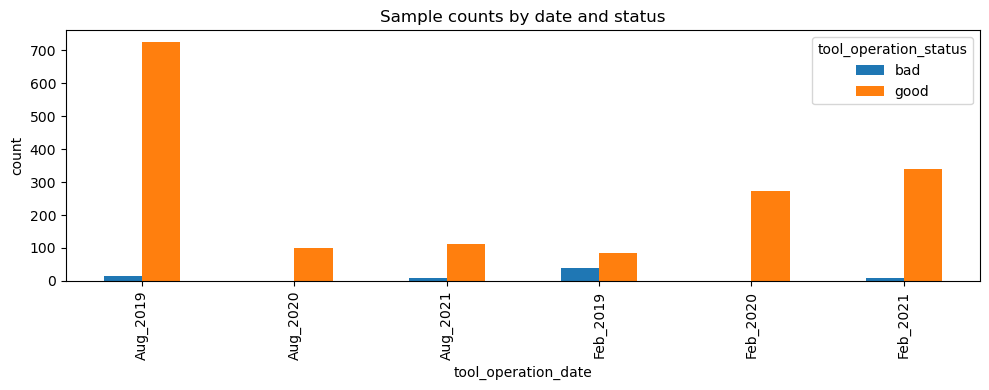

In [7]:
# Temporal distribution: counts per date and status
counts = (
    df.groupby(["tool_operation_date", "tool_operation_status"])
    .size()
    .unstack(fill_value=0)
)
display(counts)

plt.figure(figsize=(10, 4))
counts.plot(kind="bar", stacked=False, figsize=(10, 4))
plt.title("Sample counts by date and status")
plt.ylabel("count")
plt.tight_layout()
plt.show()

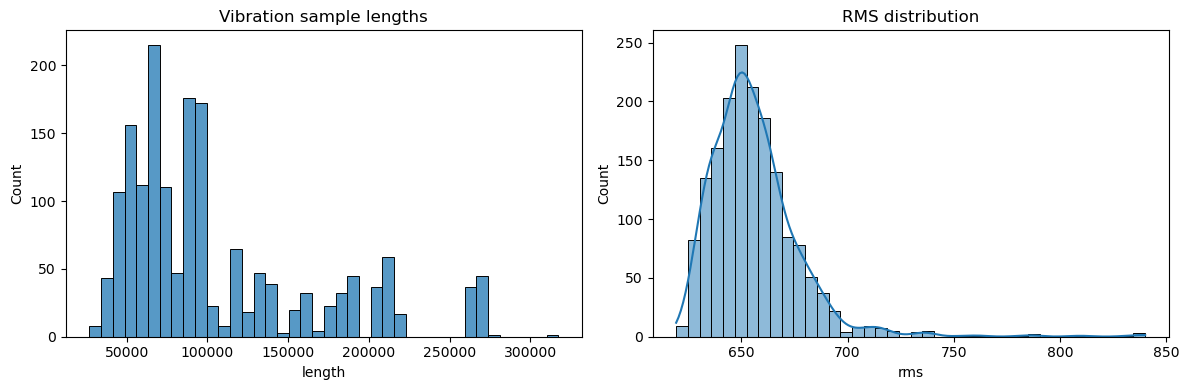

In [8]:
# Distribution plots for length and RMS
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df["length"], bins=40, kde=False)
plt.title("Vibration sample lengths")
plt.subplot(1, 2, 2)
sns.histplot(df["rms"], bins=40, kde=True)
plt.title("RMS distribution")
plt.tight_layout()
plt.show()

In [9]:
# Outlier detection on 'rms' using z-score (robust to small sets?)
rms_mean = df["rms"].mean()
rms_std = df["rms"].std(ddof=0)
df["rms_z"] = (df["rms"] - rms_mean) / (rms_std + 1e-12)
df["is_outlier_rms"] = df["rms_z"].abs() > 3.0
print("Outlier counts (RMS z>|3|):", df["is_outlier_rms"].sum())

# Show some outlier examples
if df["is_outlier_rms"].any():
    display(
        df[df["is_outlier_rms"]].head()[
            [
                "label",
                "tool_operation_date",
                "tool_operation_status",
                "length",
                "rms",
                "rms_z",
            ]
        ]
    )
else:
    print("No RMS outliers found by z>3 rule.")

Outlier counts (RMS z>|3|): 21


,label,tool_operation_date,tool_operation_status,length,rms,rms_z
55,M02_Feb_2021_OP00_000_bad,Feb_2021,bad,260000.0,787.820497,5.969086
378,M03_Feb_2021_OP02_000_bad,Feb_2021,bad,72000.0,762.891110,4.839095
515,M02_Feb_2019_OP04_000_bad,Feb_2019,bad,124731.0,738.039290,3.712621
516,M02_Feb_2019_OP04_002_bad,Feb_2019,bad,125751.0,738.481995,3.732687
701,M01_Aug_2021_OP06_000_bad,Aug_2021,bad,176000.0,738.835677,3.748719


Short samples (below 1st percentile): 18
Long samples (above 99th percentile): 12
Sample index: 55


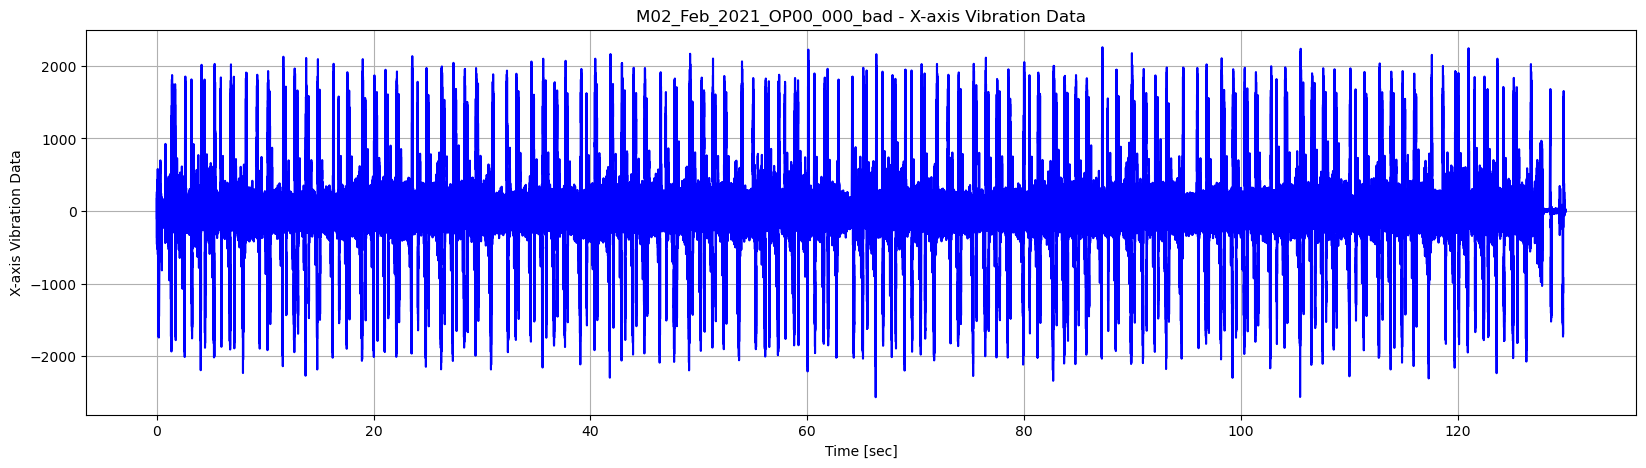

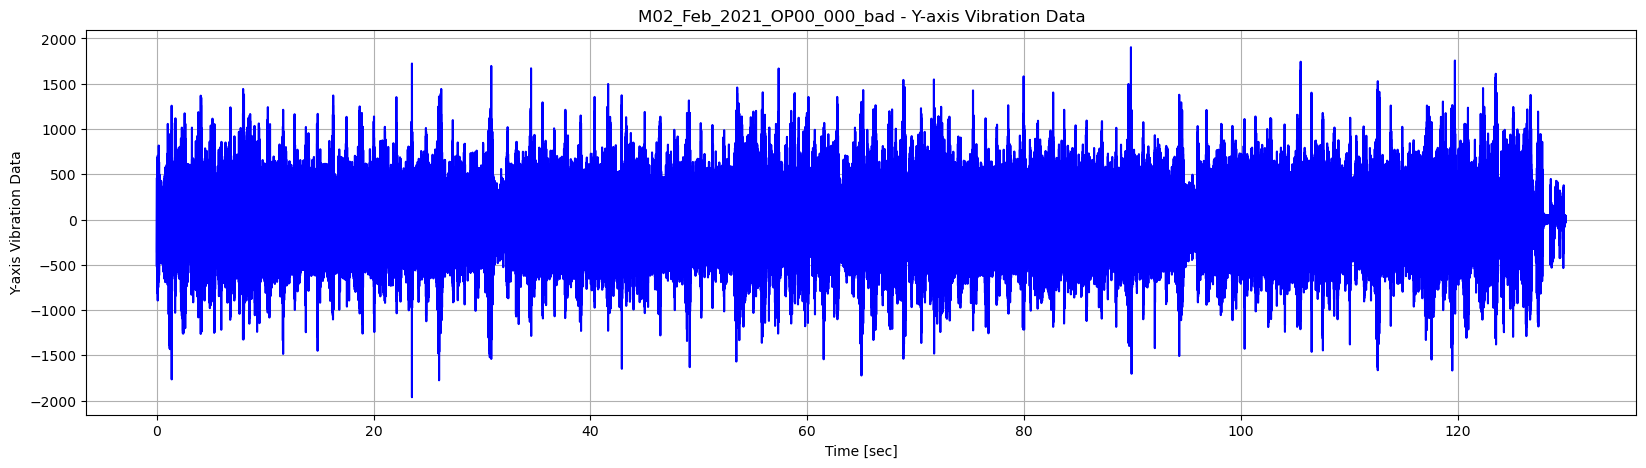

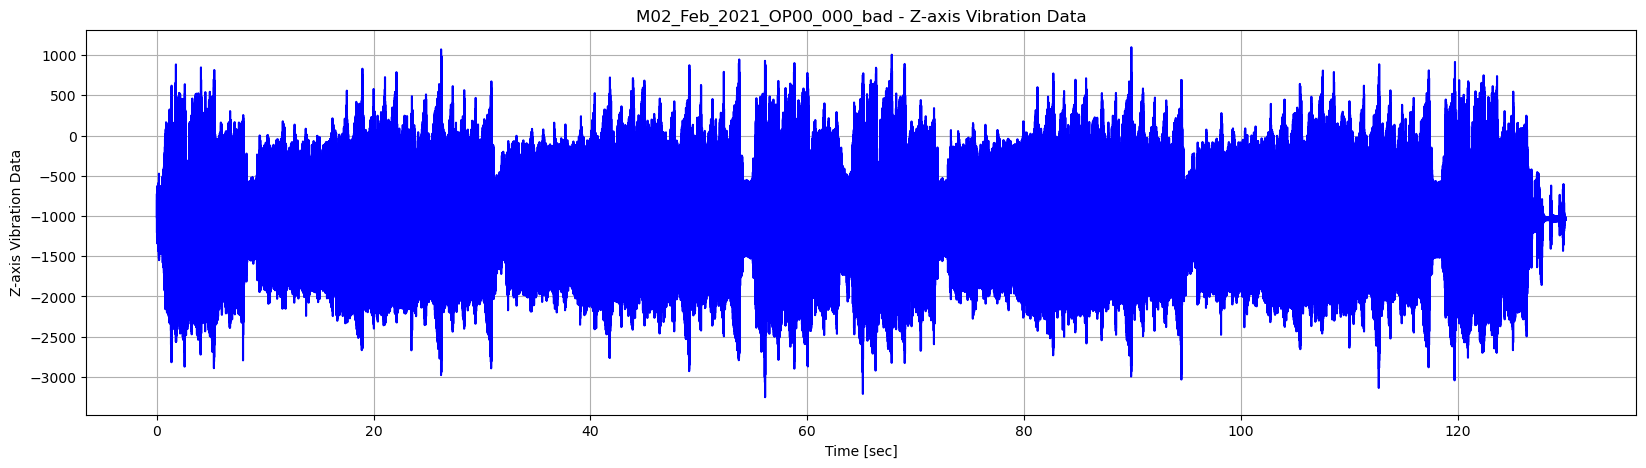

Sample index: 378


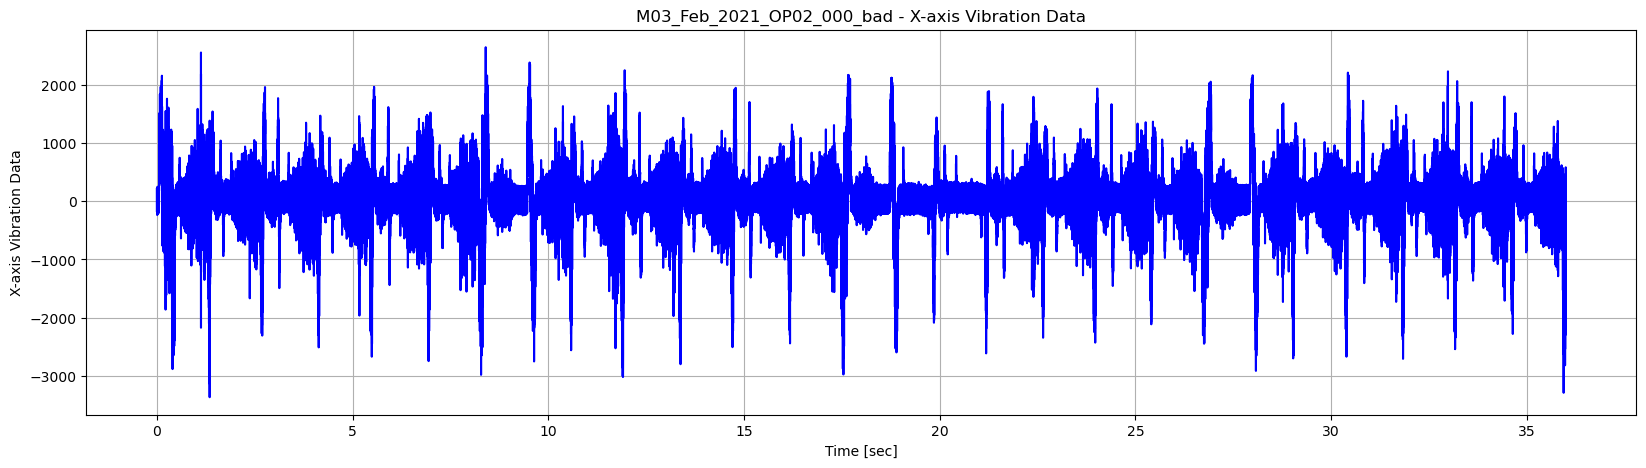

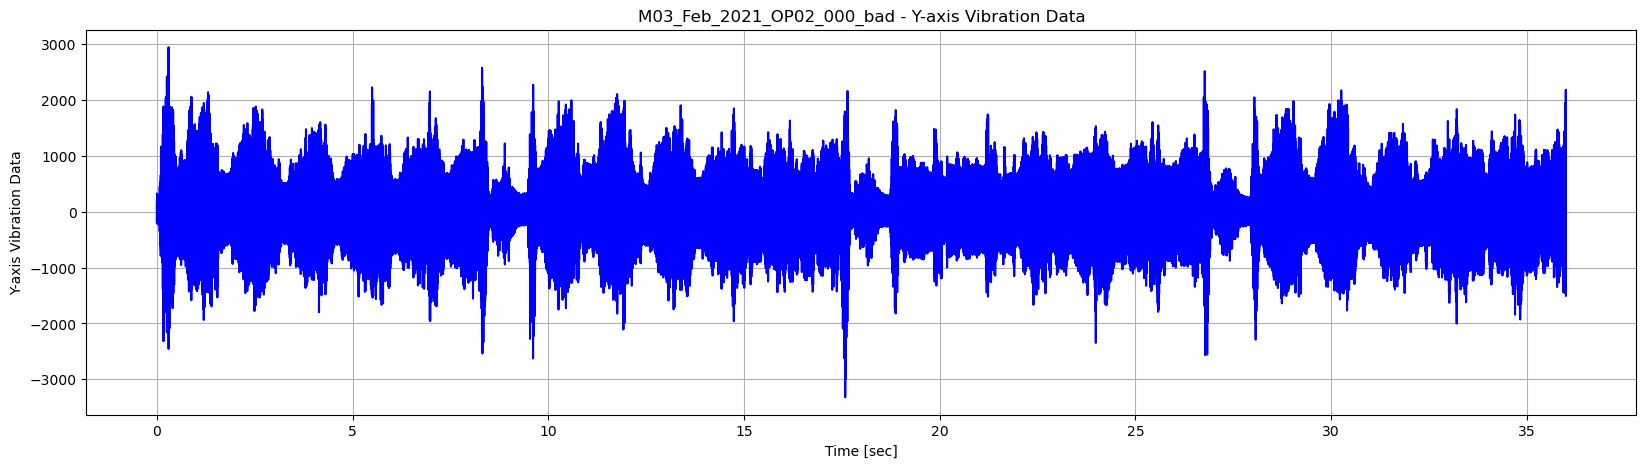

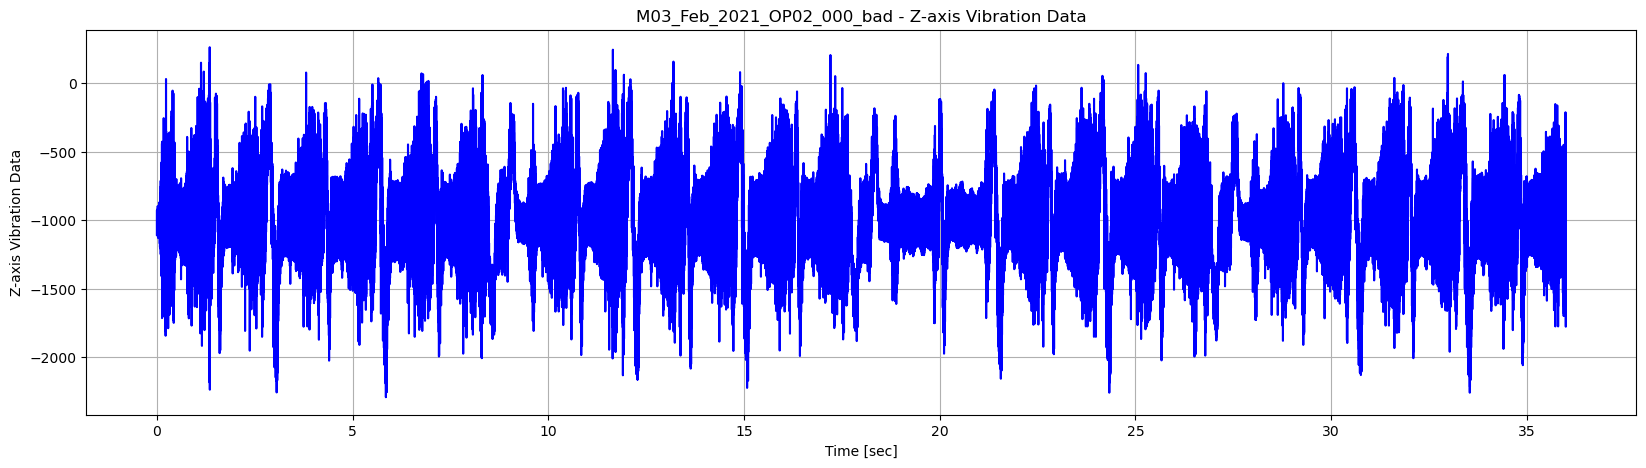

Sample index: 225


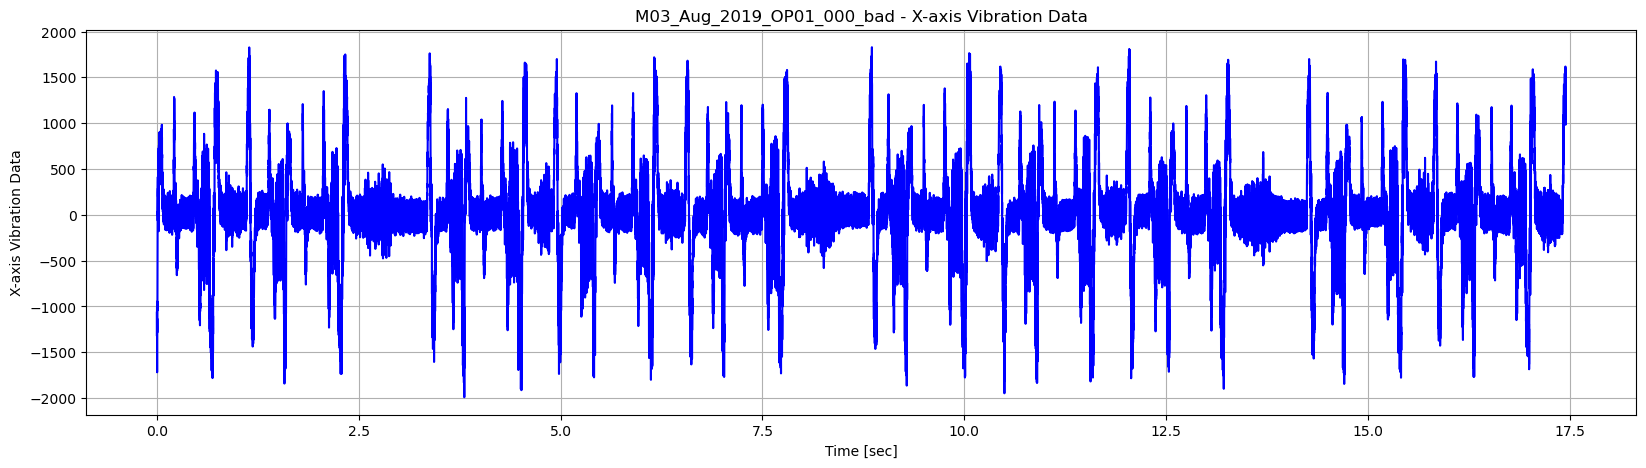

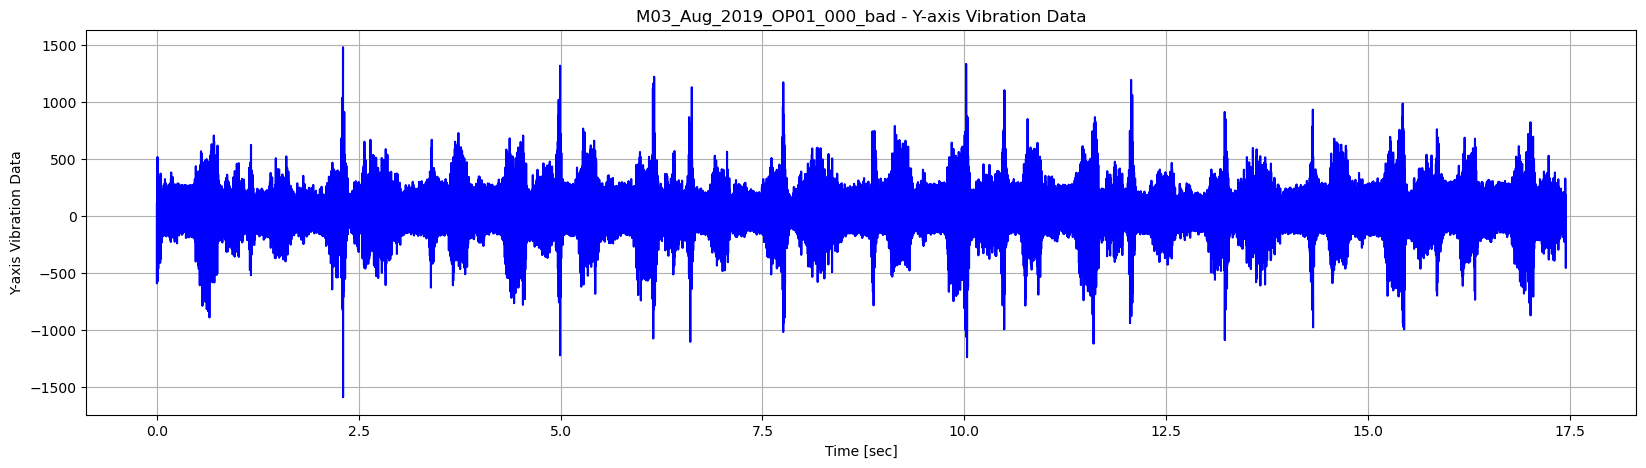

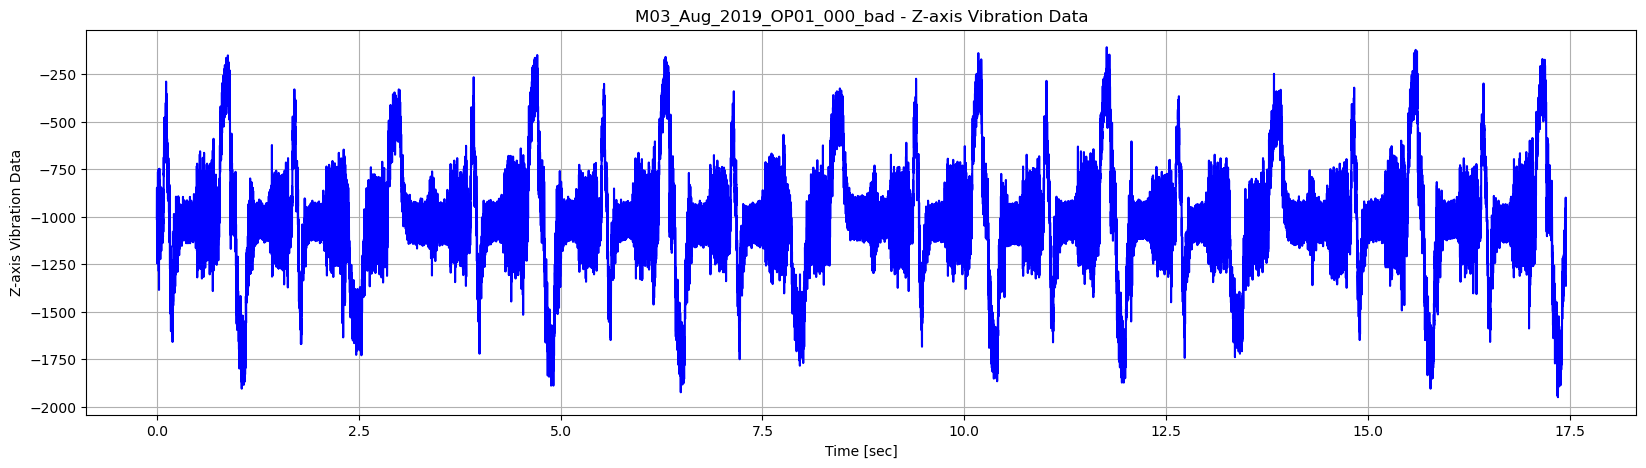

Sample index: 595


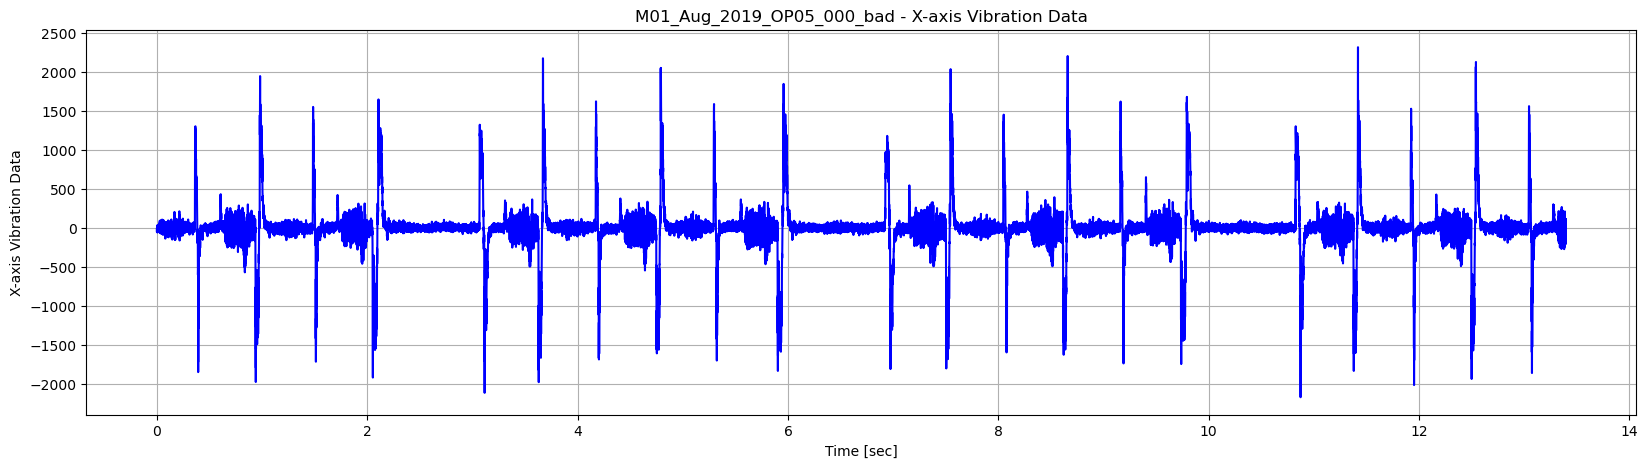

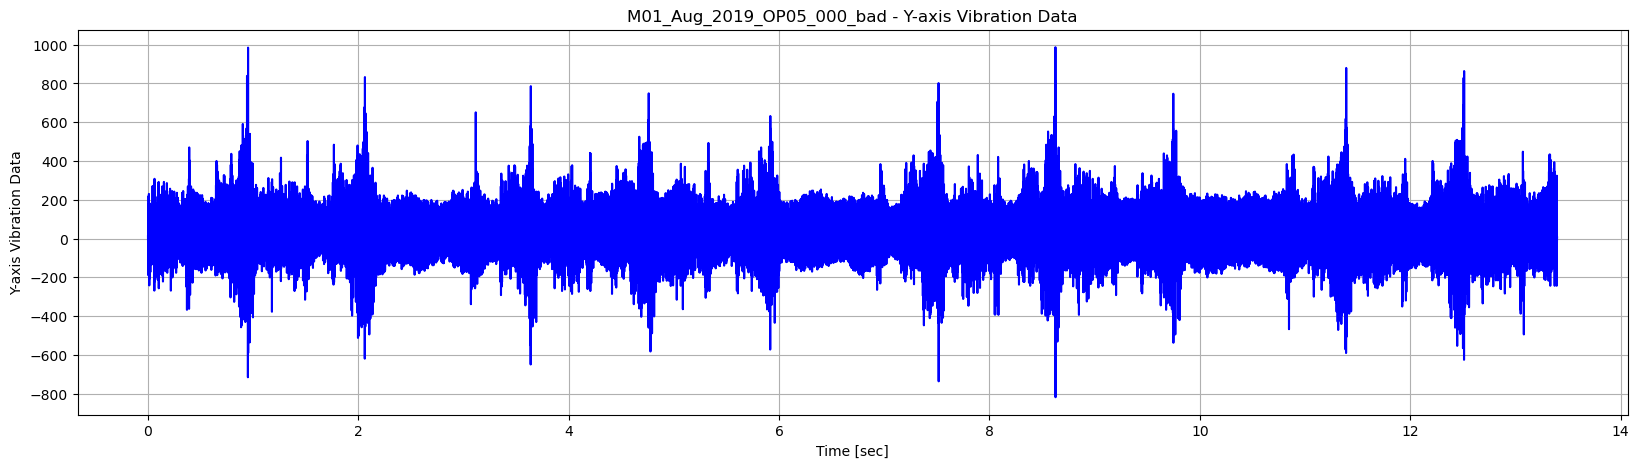

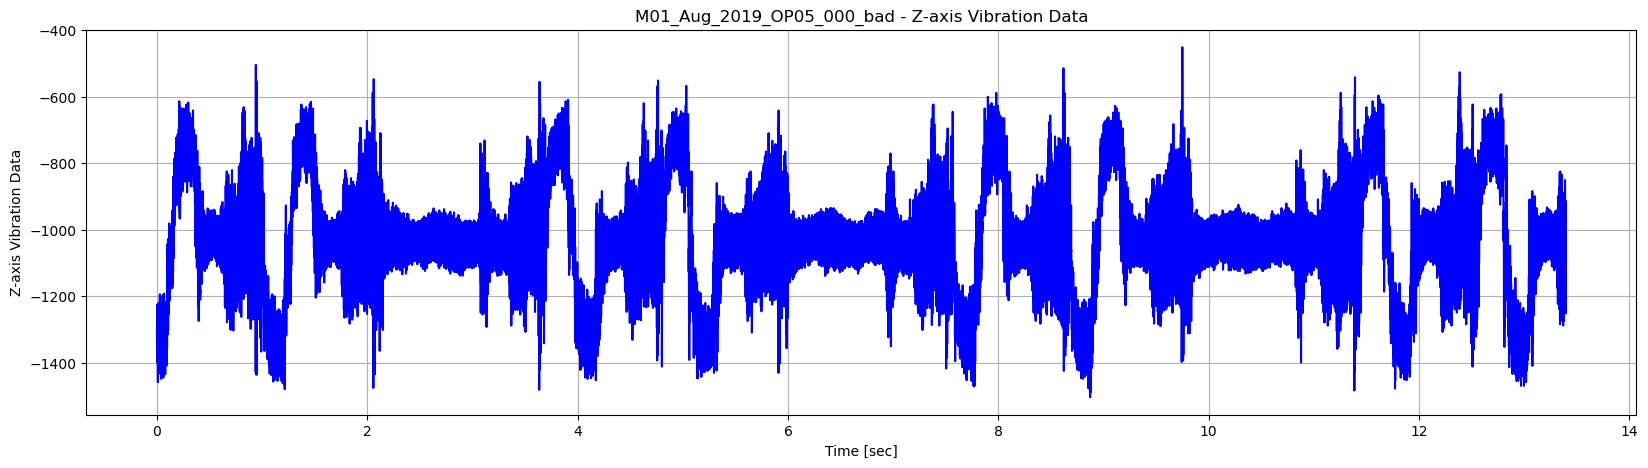

In [10]:
# Investigate samples with suspicious lengths (very short or very long)
short = df[df["length"] < df["length"].quantile(0.01)]
long = df[df["length"] > df["length"].quantile(0.99)]
print("Short samples (below 1st percentile):", len(short))
print("Long samples (above 99th percentile):", len(long))

# Visual check for a couple of outlier samples (if present)
examples = (
    df[df["is_outlier_rms"]].head(2).index.tolist() + short.head(2).index.tolist()
)
for idx in examples:
    print("Sample index:", idx)
    row = df.loc[idx]
    data_loader_utils.plot_vibration_data(row["vibration_data"], label=row["label"])

## Exploratory Data Analysis (EDA)

This EDA covers: class imbalance, feature distributions (length, RMS, max abs, means), time-series patterns aggregated by date/status, and correlation analysis among numeric features.


### Class imbalance: overall and by machine/process/date


Overall class counts:
tool_operation_status
good    1632
bad       70
Name: count, dtype: int64


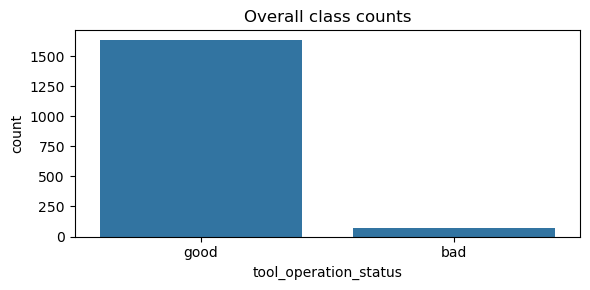

tool_operation_status,bad,good
machine_id,,
M01,34,485
M02,27,617
M03,9,530


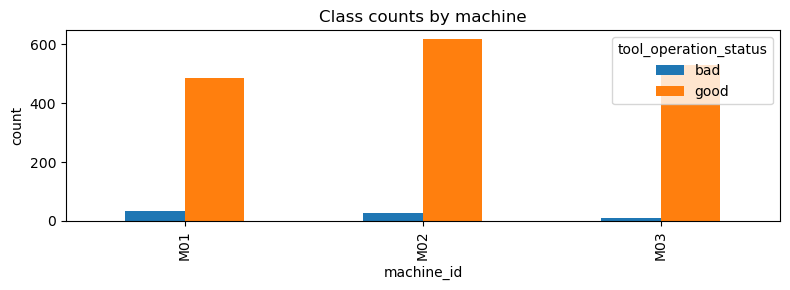

tool_operation_status,bad,good
tool_operation_id,,
OP01,7,136
OP02,4,148
OP05,6,114
OP07,10,148
OP08,7,112
OP10,7,112
OP12,5,118
OP13,0,142


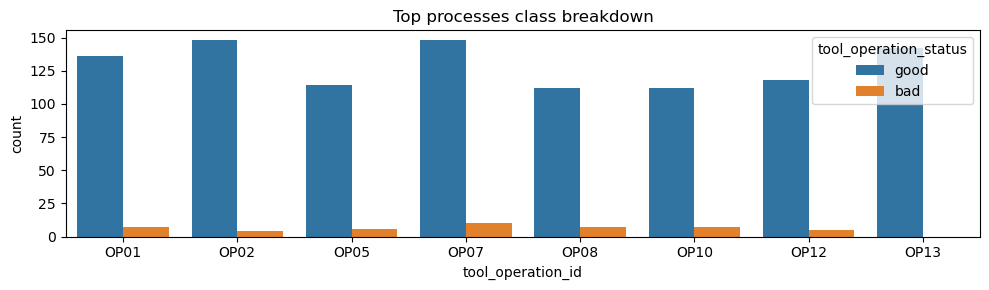

In [11]:
# Overall class imbalance
print("Overall class counts:")
print(df["tool_operation_status"].value_counts())

plt.figure(figsize=(6, 3))
sns.countplot(x="tool_operation_status", data=df)
plt.title("Overall class counts")
plt.tight_layout()
plt.show()

# By machine
by_machine = (
    df.groupby(["machine_id", "tool_operation_status"]).size().unstack(fill_value=0)
)
display(by_machine)
by_machine.plot(kind="bar", stacked=False, figsize=(8, 3))
plt.title("Class counts by machine")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# By process id (show top 8 processes by total samples)
proc_counts = df["tool_operation_id"].value_counts()
top_procs = proc_counts.head(8).index.tolist()
display(
    df[df["tool_operation_id"].isin(top_procs)]
    .groupby(["tool_operation_id", "tool_operation_status"])
    .size()
    .unstack(fill_value=0)
)
plt.figure(figsize=(10, 3))
sns.countplot(
    data=df[df["tool_operation_id"].isin(top_procs)],
    x="tool_operation_id",
    hue="tool_operation_status",
)
plt.title("Top processes class breakdown")
plt.tight_layout()
plt.show()

### Feature distributions: length, rms, max_abs, and means


,length,rms,max_abs,mean_x,mean_y,mean_z
count,1702.000000,1702.000000,1702.000000,1702.000000,1702.000000,1702.000000
mean,104936.098707,656.132980,2734.856052,3.342817,17.375085,-1024.768130
std,60507.876966,22.068073,1183.608778,6.169227,12.854840,8.802328
min,26793.000000,619.257776,1774.000000,-8.565300,-3.146913,-1050.753033
25%,62747.000000,643.006082,2131.000000,-1.335673,4.274453,-1032.048423
50%,87040.000000,652.621494,2330.000000,1.787200,17.785556,-1021.494456
75%,130048.000000,664.743206,2684.000000,9.663662,30.413069,-1016.142065
max,317440.000000,840.067122,9234.000000,24.799726,90.018052,-1006.618941


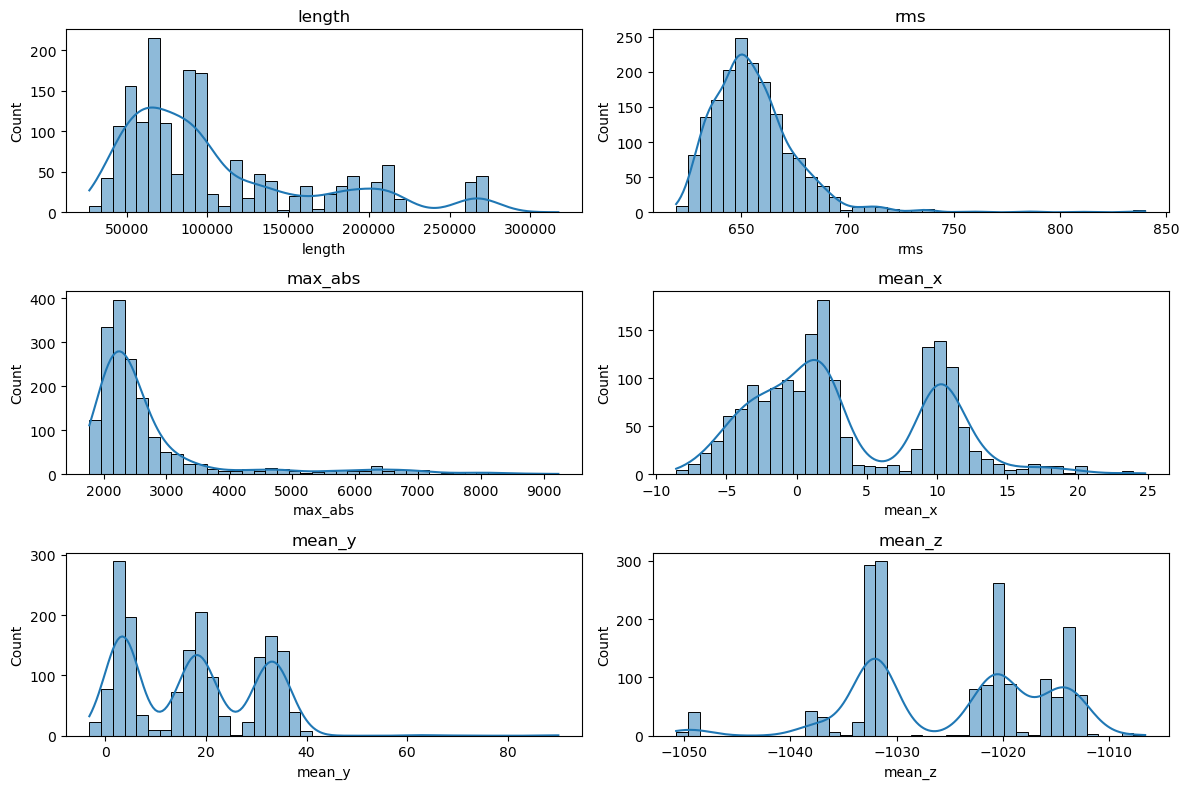

In [12]:
num_cols = ["length", "rms", "max_abs", "mean_x", "mean_y", "mean_z"]
display(df[num_cols].describe())

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i + 1)
    sns.histplot(df[col].dropna(), bins=40, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

### Violin plots of RMS by status


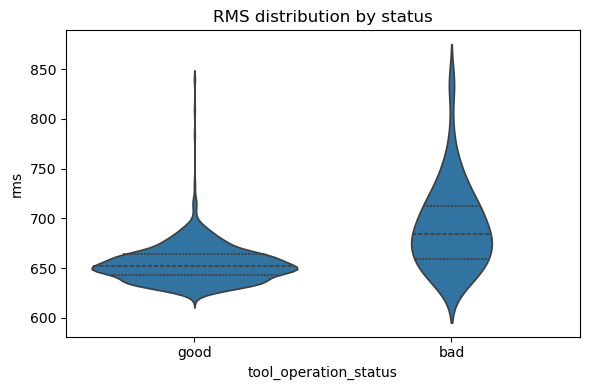

In [13]:
plt.figure(figsize=(6, 4))
sns.violinplot(x="tool_operation_status", y="rms", data=df, inner="quartile")
plt.title("RMS distribution by status")
plt.tight_layout()
plt.show()

### Time-series pattern: mean RMS per date and status


tool_operation_status,bad,good
tool_operation_date,,
Aug_2019,677.564000,652.509151
Aug_2020,NaN,669.116711
Aug_2021,701.212066,654.138422
Feb_2019,691.461866,654.402592
Feb_2020,NaN,658.444279
Feb_2021,705.511796,652.025840


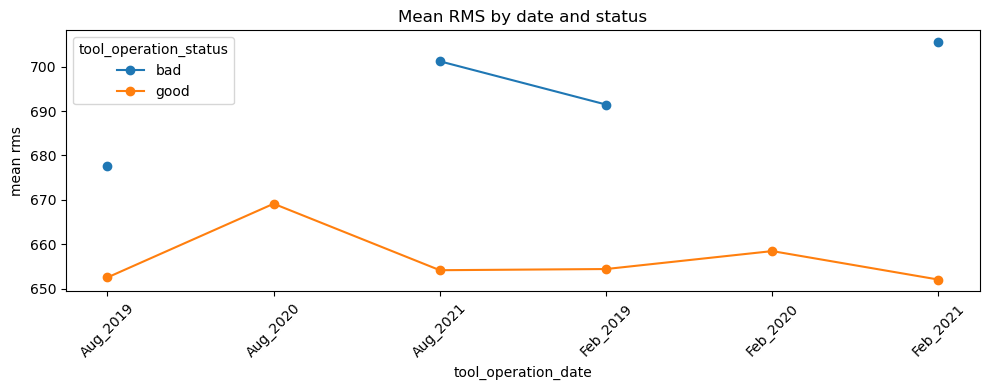

In [14]:
ts = (
    df.groupby(["tool_operation_date", "tool_operation_status"])["rms"].mean().unstack()
)
display(ts)

ts.plot.line(marker="o", figsize=(10, 4))
plt.title("Mean RMS by date and status")
plt.ylabel("mean rms")
plt.xlabel("tool_operation_date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation analysis among numeric features


Top correlations (absolute)


corr_coeff
mean_y  mean_z     0.677439
max_abs mean_x     0.458031
rms     max_abs    0.278489
        mean_x     0.267179
mean_x  mean_z    -0.211996
max_abs mean_z     0.203624
mean_x  mean_y    -0.172088
rms     mean_z    -0.163258
length  mean_x    -0.077292
        max_abs    0.068136
rms     mean_y    -0.059379
length  mean_z     0.054546
max_abs mean_y     0.046638
length  mean_y     0.021751
        rms        0.003301

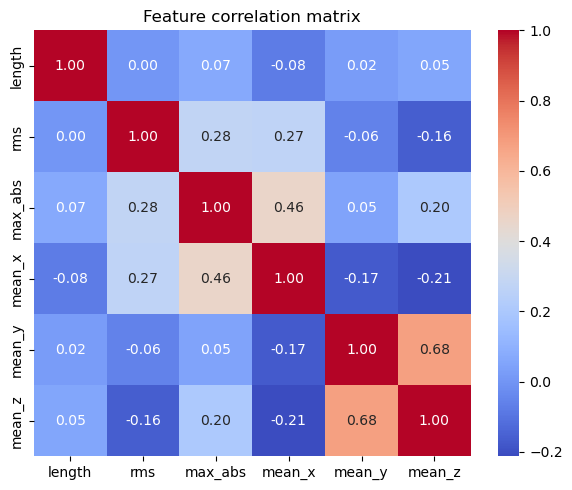

In [15]:
corr = df[num_cols].corr()
print("Top correlations (absolute)")
corr_df = pd.DataFrame(corr.unstack(), columns=["corr_coeff"])
corr_df["abs_corr"] = corr_df["corr_coeff"].abs()
duplicate_labels = [(col, col) for col in num_cols]
checked_lables = []
for label in corr_df.index:
    checked_lables.append(label)
    reversed_label = (label[1], label[0])
    if reversed_label in checked_lables:
        continue
    if reversed_label in corr_df.index:
        duplicate_labels.append(reversed_label)
display(
    corr_df.sort_values(by="abs_corr", ascending=False)
    .drop(labels=duplicate_labels)
    .drop(columns=["abs_corr"])
)
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()